# This notebook creates the entire pipeline for the bikelane classifier model

In [2]:
# imports

# General imports
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Preprocessing and feature engineering imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.fft import fft, fftfreq
from scipy import signal as sg
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from sklearn.decomposition import PCA

# imports for model production and evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

## 1. Load in the data

In [3]:
def load_data(general_path):
    data_dict = {}
    for dir in os.listdir(general_path): # loops over each folder in the data folder
        path = general_path + "/" + dir
        data_list = os.listdir(path) # list of all the csv files of a run

        df_accelerometer = pd.read_csv(path + "/" + data_list[0]) # extract accelerometer data of each run
        df_accelerometer = df_accelerometer.add_prefix("accelerometer_")

        df_gravity = pd.read_csv(path + "/" + data_list[3]) # extract gravity data of each run
        df_gravity = df_gravity.add_prefix("gravity_")

        df_gyroscope = pd.read_csv(path + "/" + data_list[4]) # extract gyroscope data of each run
        df_gyroscope = df_gyroscope.add_prefix("gyroscope_")

        # Create one large dataframe of all data of a run, and set the time to the accelerometer time (this does not matter as it is internal per run)
        total_df = pd.concat([df_accelerometer, df_gravity, df_gyroscope], axis=1) 
        total_df["time"] = total_df["accelerometer_time"]
        total_df["seconds_elapsed"] = total_df["accelerometer_seconds_elapsed"]
        total_df["label"] = 0 if str(data_list).startswith('1') else 1

        # Remove redundant columns that contain the same time
        cols_to_drop = [col for col in total_df.columns if col.endswith("_time") or col.endswith("_seconds_elapsed")]
        total_df = total_df.drop(columns=cols_to_drop)

        data_dict[dir] = total_df # Add dataframe to dictionary in which the name of the run is the key, and the dataframe is the value

    return data_dict

data_dict = load_data("data")
# Show sample output and how to reach the dataframes
for keys, values in data_dict.items():
    print(values.head())

   accelerometer_z  accelerometer_y  accelerometer_x  gravity_z  gravity_y  \
0         0.000000         0.000000         0.000000   9.542088   2.046156   
1        -0.050701         0.027020        -0.038673   9.527453   2.119188   
2        -0.149875        -0.009949        -0.102333   9.517285   2.167532   
3        -0.188336        -0.026751        -0.021749   9.503442   2.207882   
4        -0.066349        -0.022494         0.142544   9.486468   2.240596   

   gravity_x  gyroscope_z  gyroscope_y  gyroscope_x                 time  \
0   0.965502     0.340557     0.039859     0.451276  1789033866714703400   
1   0.952396     0.273973    -0.135459     0.435394  1789033866724628700   
2   0.945237     0.203723    -0.307112     0.409738  1789033866734553900   
3   0.990071     0.136528    -0.451887     0.387746  1789033866744479200   
4   1.075659     0.068722    -0.520915     0.379805  1789033866754404400   

   seconds_elapsed  label  
0         0.059703      1  
1         0.069629

## 2. Preprocessing the data

### 2.1 Create train and test sets --> nog niet af

In [4]:
def leave_one_out_paired(data, seed=42):
    good_ids = [id_ for id_ in data if str(id_).startswith('1')]
    bad_ids  = [id_ for id_ in data if str(id_).startswith('2')]

    n_folds = max(len(good_ids), len(bad_ids))

    for i in range(n_folds):
        held_good = good_ids[i] if i < len(good_ids) else None
        held_bad  = bad_ids[i] if i < len(bad_ids) else None

        held = {}
        if held_good is not None:
            held[held_good] = data[held_good]
        if held_bad is not None:
            held[held_bad] = data[held_bad]

        test_runs = held
        train_runs = {id_: df for id_, df in data.items() if id_ not in held}

        yield train_runs, test_runs

In [5]:
for fold, (train_runs, test_runs) in enumerate(leave_one_out_paired(data_dict)):
    print(f"Fold {fold}: held out {list(test_runs.keys())}")
    # train your model on train_runs, evaluate on test_runs

Fold 0: held out ['1_Goede_weg_ah_1', '2_johannesbuijslaan_tot_van_vollenhovenstraat-2026-09-19_06-31-44']
Fold 1: held out ['1_Goede_weg_PetrusDondersstraat_Mathijs_08_22_1509-2026-09-15_06-22-43', '2_lievendaalseweg_tot_deel_loeffstraat-2026-09-19_06-33-01']
Fold 2: held out ['1_Goede_weg_sintjorislaan_Mathijs_08_25_1509-2026-09-15_06-25-31', '2_simon_van_leeuwenstraat_tot_rodenburgweg-2026-09-19_06-34-02']
Fold 3: held out ['1_Goede_weg_tunnel_uni_1', '2_Slechte_weg_Akkerstraat_Mathijs_08_36_1509-2026-09-15_06-36-43']
Fold 4: held out ['1_Goede_weg_tunnel_uni_2', '2_Slechte_weg_Mathijs_08_30_1509-2026-09-15_06-30-11']
Fold 5: held out ['1_goed_fietspad_tot_apeldoornstraat-2026-09-19_06-28-17', '2_Slechte_weg_pathe_1']
Fold 6: held out ['1_goed_fietspad_tot_merulastraat-2026-09-19_06-25-30', '2_Slechte_weg_pathe_2']
Fold 7: held out ['1_goed_fietspad_tot_oude_vensedijk-2026-09-19_06-26-43']


### 2.2 Trim each run symmetrically to a duration of 30 seconds, so each sample has the same length

In [6]:
def trim_to_30s(df):
    """Trims dataframe symmetrically to a duration of 30 seconds."""
    start_time = df['seconds_elapsed'].min()
    end_time = df['seconds_elapsed'].max()
    total_duration = end_time - start_time
    
    if total_duration > 30:
        trim_amount = (total_duration - 30) / 2
        new_start = start_time + trim_amount
        new_end = end_time - trim_amount
        
        # Filter rows within the 30-second window and reset elapsed time from 0
        df_trimmed = df[(df['seconds_elapsed'] >= new_start) & (df['seconds_elapsed'] <= new_end)].copy()
        df_trimmed['seconds_elapsed'] = df_trimmed['seconds_elapsed'] - new_start
        return df_trimmed
    return df

### 2.3 Frequency filtering of the signal

In [7]:
def butter_bandpass(lowcut, highcut, fs, order=2):
    """Design a Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = sg.butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=2):
    """Apply the bandpass filter to a data array."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return sg.lfilter(b, a, data)

def butter_highpass(lowcut, fs, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    b, a = sg.butter(order, low, btype='high')
    return b, a

def highpass_filter(data, lowcut, fs, order=2):
    """Apply the bandpass filter to a data array."""
    b, a = butter_highpass(lowcut, fs, order=order)
    return sg.lfilter(b, a, data)

### 2.4 Averaging of the data

In [8]:
def average_data(data, columns_to_average, window_size=10):
    data = data.copy()
    data[columns_to_average] = data[columns_to_average].rolling(window=window_size, min_periods=1).mean()
    return data

### 2.5 Normalizing data

In [9]:
def fit_scaler(data, feature_cols):
    all_train_features = pd.concat([df[feature_cols] for df in data], axis=0)
    scaler = StandardScaler()
    scaler.fit(all_train_features)
    return scaler

def scale_data(df, scaler, feature_cols):
    df = df.copy()
    df[feature_cols] = scaler.transform(df[feature_cols])
    return df

### 2.6 Windowing the data and extracting features

In [16]:
def windows_and_features(df,features, window_size_sec=2.0, overlap=0.5, fs=100.0):
    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))
        
    features_list = []
    window_list = []

    for i in features:
        for start in range(0, len(df) - window_size_samples, step_size):
            window = df.iloc[start:start + window_size_samples]
            sig = window[i]

            # Extract features per window
            feat = {
                'input' : i,
                'mean': sig.mean(),
                'std': sig.std(),
                'rms': np.sqrt(np.mean(sig**2)),
                'peak_to_peak': sig.max() - sig.min(),
                'iqr': np.percentile(sig, 75) - np.percentile(sig, 25),
                'skewness': skew(sig),
                'kurtosis': kurtosis(sig)
                    }
            features_list.append(feat)
            
            window = {
                    'input' : i,
                    'window_start_idx': start,
                    'raw_signal': sig.values,  # stores the full array in one cell
                    'mean': sig.mean(),
                    'std': sig.std(),
                                    }
            window_list.append(window)
                    
    return pd.DataFrame(features_list),  pd.DataFrame(window_list)

2.7 Feature extraction through power spectral density.


In [ ]:
# Example usage of total pipeline, here used to setup data_dict 
important_data = ['accelerometer_x', 'accelerometer_y', "accelerometer_z",
                  'gravity_x', 'gravity_y', 'gravity_z',
                  'gyroscope_x', 'gyroscope_y', 'gyroscope_z']
# Fit the scaler on all data, this makes it that bad roads still keep their more rough nature
scaler = fit_scaler(list(data_dict.values()), important_data)
all_features = []
all_windows = []
for key, df in data_dict.items():

    # Trim data run
    df_trimmed = trim_to_30s(df)

    # Average data run on interesting features
    df_trimmed_averaged = average_data(df_trimmed, important_data)

    # Scale data runs for most consistent features
    df_trimmed_averaged_scaled = scale_data(df_trimmed_averaged, scaler, important_data)

    feat_df, window_df = windows_and_features(df_trimmed_averaged_scaled, important_data)
    feat_df['source'] = key
    window_df['source'] = key
    all_features.append(feat_df)
    all_windows.append(window_df)

# add all features in a dataframe with the corresponding source and label
features = pd.concat(all_features, ignore_index=False)
features["label"] = np.where(features['source'].astype(str).str.startswith('1'), 0, 1)
print(features)

               input      mean       std       rms  peak_to_peak       iqr  \
0    accelerometer_x  0.042601  0.898642  0.897404      3.068421  1.312686   
1    accelerometer_x  0.110042  0.918504  0.922789      3.090978  1.084293   
2    accelerometer_x  0.019882  0.763514  0.761862      3.061366  0.986745   
3    accelerometer_x -0.023891  0.612969  0.611901      2.093175  0.914270   
4    accelerometer_x -0.021867  0.611931  0.610791      2.227639  0.812071   
..               ...       ...       ...       ...           ...       ...   
256      gyroscope_z -0.017422  0.797760  0.795954      3.020839  1.281126   
257      gyroscope_z  0.068808  0.637378  0.639495      2.489312  0.770826   
258      gyroscope_z  0.040730  0.442166  0.442936      1.606551  0.681592   
259      gyroscope_z -0.016857  0.357440  0.356943      1.440191  0.453841   
260      gyroscope_z -0.069577  0.210493  0.221193      0.810289  0.368417   

     skewness  kurtosis                 source  label  
0   -0.

In [18]:
#Total thingy
def windowed_band_power_features(df, columns, b=None, a=None,
                                   window_size_sec=2.0, overlap=0.5, fs=100.0,
                                   freq_band=(20, 80), nperseg=200):
    """
    Compute Welch PSD band-power features for multiple signal columns,
    windowed over a single dataframe (one data run).

    df       : dataframe for a single run (already trimmed/averaged/scaled)
    columns  : list of column names to compute PSD-based features for
    b, a     : optional filter passes. can come from butter bandpass, lowpass or higphpass.

    Returns a DataFrame with one row per window and one power column per signal,
    e.g. 'accelerometer_x_power', 'accelerometer_y_power', ...
    """
    # Optionally filter every column up front (vectorized, once per column)
    filtered = df.copy()
    if b is not None and a is not None:
        for col in columns:
            filtered[col] = sg.filtfilt(b, a, filtered[col].values)

    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))

    rows = []
    for start in range(0, len(filtered) - window_size_samples, step_size):
        window = filtered.iloc[start:start + window_size_samples]
        row = {'window_start': start, 'window_end': start + window_size_samples}

        for col in columns:
            f, Pxx = sg.welch(window[col].values, fs=fs, nperseg=nperseg)
            mask = (f >= freq_band[0]) & (f <= freq_band[1])
            row[f'{col}_power'] = trapezoid(Pxx[mask], f[mask])

        rows.append(row)

    return pd.DataFrame(rows)

all_features = []
all_windows = []
all_power_features = []

for key, df in data_dict.items():
    df_trimmed = trim_to_30s(df)
    df_trimmed_averaged = average_data(df_trimmed, important_data)
    df_trimmed_averaged_scaled = scale_data(df_trimmed_averaged, scaler, important_data)

    feat_df, window_df = windows_and_features(df_trimmed_averaged_scaled, important_data)
    feat_df['source'] = key
    window_df['source'] = key

    # New: per-variable PSD band power, one row per window
    power_df = windowed_band_power_features(
        df_trimmed_averaged_scaled, important_data,
        b=None, a=None, window_size_sec=2.0, overlap=0.5, fs=100.0, freq_band=(20, 80)
    )
    power_df['source'] = key

    all_features.append(feat_df)
    all_windows.append(window_df)
    all_power_features.append(power_df)

features = pd.concat(all_features, ignore_index=False)
power_features = pd.concat(all_power_features, ignore_index=True)

features["label"] = np.where(features['source'].astype(str).str.startswith('1'), 0, 1)
power_features["label"] = np.where(power_features['source'].astype(str).str.startswith('1'), 0, 1)

print( power_features.head())

   window_start  window_end  accelerometer_x_power  accelerometer_y_power  \
0             0         200               0.000030               0.000035   
1           100         300               0.000020               0.000035   
2           200         400               0.000018               0.000033   
3           300         500               0.000012               0.000020   
4           400         600               0.000030               0.000040   

   accelerometer_z_power  gravity_x_power  gravity_y_power  gravity_z_power  \
0               0.000155     3.439231e-10     1.095040e-09     2.806224e-09   
1               0.000147     1.677172e-10     5.372223e-10     3.023492e-09   
2               0.000098     1.561613e-10     4.936907e-10     1.761671e-09   
3               0.000087     6.006814e-11     4.491602e-10     1.032283e-09   
4               0.000106     2.212325e-10     9.421923e-10     1.481261e-09   

   gyroscope_x_power  gyroscope_y_power  gyroscope_z_power    

In [19]:
from sklearn.feature_selection import mutual_info_regression

def mutual_info_matrix(feature_df, log_transform=True):
    """
    feature_df: rows = variables, columns = features (e.g. frequency bins).
    Returns a symmetric MI matrix.
    """
    X = feature_df.copy()
    if log_transform:
        X = np.log1p(X)  # PSDs are heavy-tailed; log helps the KNN-based estimator

    cols = X.index          # variables
    n = len(cols)
    mi_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    Xt = X.T  # rows = samples (windows), columns = variables 

    for target in cols:
        y = X.loc[target].values
        mi = mutual_info_regression(Xt.values, y, random_state=0)
        mi_matrix.loc[:, target] = mi

    # symmetrization by taking the average of the MI(X;Y) and MI(Y;X) estimates
    mi_matrix = (mi_matrix + mi_matrix.T) / 2
    return mi_matrix


power_cols = [f'{col}_power' for col in important_data]

mi_mat = mutual_info_matrix(power_features[power_cols].T)


from sklearn.feature_selection import mutual_info_classif

#The mutual between the power features and label show which features are most informative for classification.
mi_vs_label = mutual_info_classif(power_features[power_cols], power_features['label'], random_state=0)
pd.Series(mi_vs_label, index=power_cols).sort_values(ascending=False)

accelerometer_x_power    0.458864
gyroscope_z_power        0.441442
gyroscope_x_power        0.411876
accelerometer_z_power    0.403552
gyroscope_y_power        0.402298
accelerometer_y_power    0.389194
gravity_y_power          0.329067
gravity_z_power          0.294682
gravity_x_power          0.242172
dtype: float64

In [ ]:
#test for statistic significance of the mutual information.
n_permutations = 200
null_mi = np.zeros((n_permutations, len(power_cols)))

for i in range(n_permutations):
    shuffled_label = np.random.permutation(power_features['label'].values)
    null_mi[i] = mutual_info_classif(power_features[power_cols], shuffled_label, random_state=i)

# 95th percentile of null distribution per feature = rough significance threshold
null_threshold = np.percentile(null_mi, 95, axis=0)
pd.DataFrame({'mi': mi_vs_label, 'null_95th': null_threshold}, index=power_cols)

,mi,null_95th
accelerometer_x_power,0.458864,0.040553
accelerometer_y_power,0.389194,0.043340
accelerometer_z_power,0.403552,0.036584
gravity_x_power,0.242172,0.042891
gravity_y_power,0.329067,0.039209
gravity_z_power,0.294682,0.033186
gyroscope_x_power,0.411876,0.038615
gyroscope_y_power,0.402298,0.038052
gyroscope_z_power,0.441442,0.039687


### 3.6 Create windows and extract the features

### Preparing the Dataset and Defining Features

This step merges the feature datasets for good and bad roads into a single master dataframe. Binary class labels (`target`) are assigned to distinguish between road conditions: `0` represents a good road and `1` represents a bad road. 

The feature set consists of the seven statistical metrics extracted from the accelerometer sliding windows (`mean`, `std`, `rms`, `peak_to_peak`, `iqr`, `skewness`, and `kurtosis`). Furthermore, the `source` column is designated as the group variable for cross-validation to prevent data leakage by keeping individual trips entirely separated between training and test sets.

In [64]:
# Kopieer en label de data
df_ml_good = features_good.copy()
df_ml_bad = features_bad.copy()

df_ml_good['target'] = 0  # Goede weg = 0
df_ml_bad['target'] = 1   # Slechte weg = 1

# Samenvoegen tot één master dataframe voor ML
df_ml = pd.concat([df_ml_good, df_ml_bad], ignore_index=True)

# Definieer welke kolommen je als features wilt gebruiken
feature_cols = ['mean', 'std', 'rms', 'peak_to_peak', 'iqr', 'skewness', 'kurtosis']

X = df_ml[feature_cols]
y = df_ml['target']
groups = df_ml['source']  # Nodig voor  cross-validation

print(f"Dataset vorm (X): {X.shape}")
print(f"Aantal unieke ritten (groups): {groups.nunique()}")

Dataset vorm (X): (435, 7)
Aantal unieke ritten (groups): 15


### Data Splitting and Feature Scaling

This step sets up a robust cross-validation strategy using `GroupKFold` with 5 splits based on the `source` column (individual trips). This ensures that data from the same trip never leaks across both the training and testing sets. 

The first fold is extracted to serve as the standard train/test split for training and evaluating the machine learning models. Additionally, a `StandardScaler` is applied to normalize the feature matrices (`X_train` and `X_test`), scaling them to have a mean of 0 and a standard deviation of 1, which is essential for distance-based algorithms.

In [65]:
# GroupKFold met 5 folds (groupKFold zorgt ervoor dat samples van dezelfde rit niet in zowel train als test set zitten)
gkf = GroupKFold(n_splits=5)

# Haal de eerste fold op als onze standaard train/test split voor latere modellen
train_idx, test_idx = next(gkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Feature scaling (optioneel, voor sommige modellen zoals SVM of Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Aantal samples in Train set: {len(X_train)} (Ritten in train: {df_ml.iloc[train_idx]['source'].nunique()})")
print(f"Aantal samples in Test set: {len(X_test)} (Ritten in test: {df_ml.iloc[test_idx]['source'].nunique()})")

Aantal samples in Train set: 348 (Ritten in train: 12)
Aantal samples in Test set: 87 (Ritten in test: 3)


### Model Evaluation and Visualization Function

This step defines a reusable evaluation function (`evaluate_model`) to assess the performance of trained machine learning models. It generates predictions on the test set and calculates the overall accuracy alongside a detailed classification report containing precision, recall, and f1-score for both classes (`Good Road` and `Bad Road`). Additionally, it plots a visually clear confusion matrix using a seaborn heatmap to show the distribution of correct and incorrect predictions.

In [66]:
def evaluate_model(model, X_te, y_te, model_name="Model"):
    """Evalueer een getraind model en print de resultaten overzichtelijk."""
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    print(f"--- Evaluatie voor: {model_name} ---")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['Good Road (0)', 'Bad Road (1)']))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
def evaluate_model(model, X_te, y_te, model_name="Model"):
    """Evalueer een getraind model en print de resultaten overzichtelijk."""
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    print(f"--- Evaluatie voor: {model_name} ---")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['Good Road (0)', 'Bad Road (1)']))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

### Training and Evaluating the Random Forest Classifier

This step trains a Random Forest classifier using the extracted feature set and evaluates its performance with the previously defined evaluation function. Since tree-based models are scale-invariant, the unscaled training and test sets are used. The resulting accuracy and confusion matrix provide clear insights into the model's capability to correctly classify good and bad road conditions.

--- Evaluatie voor: Random Forest ---
Accuracy: 0.8046

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.66      0.86      0.75        29
 Bad Road (1)       0.92      0.78      0.84        58

     accuracy                           0.80        87
    macro avg       0.79      0.82      0.79        87
 weighted avg       0.83      0.80      0.81        87



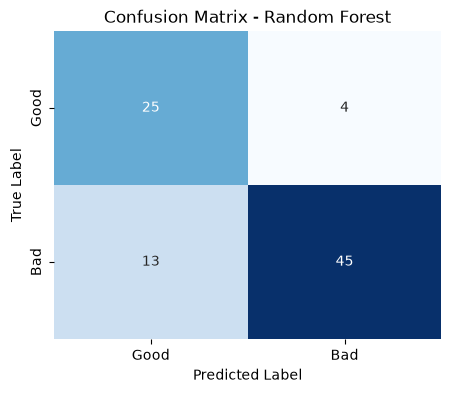

In [67]:
# Voorbeeld voor Model 1: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train) # Of X_train_scaled

evaluate_model(rf_model, X_test, y_test, model_name="Random Forest")

### Training and Evaluating the Isolation Forest Model

This step trains an unsupervised Isolation Forest model on the training data without using class labels. The model identifies anomalies based on the contamination parameter, which estimates the proportion of outliers (bad roads) in the dataset. Predictions output `-1` for anomalies and `1` for normal instances, which are then remapped to match the binary target labels (`1` for bad roads and `0` for good roads). Finally, the model's performance is evaluated using accuracy, precision, recall, and f1-score.

In [68]:
# Initialiseer en train het Isolation Forest zonder labels
# contamination is het geschatte percentage slechte wegen
iso_forest = IsolationForest(contamination=0.5, random_state=42)
iso_forest.fit(X_train)

# Voorspellen op de testset
# Isolation Forest geeft 1 voor normale data (goed) en -1 voor afwijkingen (slecht)
raw_preds = iso_forest.predict(X_test)

# Mappen naar correcte labels: -1 (outlier/slecht) wordt 1, en 1 (normaal/goed) wordt 0
y_pred_iso = [1 if p == -1 else 0 for p in raw_preds]

# Model evalueren 
print("--- Evaluatie Unsupervised: Isolation Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_iso):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_iso, target_names=['Good Road (0)', 'Bad Road (1)']))

--- Evaluatie Unsupervised: Isolation Forest ---
Accuracy: 0.4253

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.11      0.10      0.11        29
 Bad Road (1)       0.57      0.59      0.58        58

     accuracy                           0.43        87
    macro avg       0.34      0.34      0.34        87
 weighted avg       0.41      0.43      0.42        87



### Training and Evaluating the Naive Bayes Classifier

This step trains a Gaussian Naive Bayes classifier on the training set. Since Naive Bayes relies on the assumption of conditional independence between features, it provides an interesting baseline to test against feature correlation in the accelerometer data. The model predicts road conditions on the test set, and its performance is evaluated using accuracy, precision, recall, and f1-score.

In [69]:
# Initialiseren en trainen
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Voorspellen en evalueren
y_pred_nb = nb_model.predict(X_test)
print("--- Evaluatie: Naive Bayes ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=['Good Road (0)', 'Bad Road (1)']))

--- Evaluatie: Naive Bayes ---
Accuracy: 0.5747

               precision    recall  f1-score   support

Good Road (0)       0.43      0.83      0.56        29
 Bad Road (1)       0.84      0.45      0.58        58

     accuracy                           0.57        87
    macro avg       0.63      0.64      0.57        87
 weighted avg       0.70      0.57      0.58        87



### Training and Evaluating the K-Means Clustering Model

This step trains an unsupervised K-Means clustering model with two clusters on the training features without utilizing class labels. Since clustering algorithms output arbitrary cluster identifiers rather than binary classes, a mapping strategy is implemented: the model evaluates cluster alignment on the training set to determine whether the cluster labels should be inverted. This derived mapping is then applied to the test set predictions, and the final classification performance is evaluated using accuracy, precision, recall, and f1-score.

In [70]:
# 1. K-Means instellen en trainen op X_train
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train) 

# 2. Voorspellen op de TRAININGSSET om de mapping te bepalen
train_cluster_preds = kmeans.predict(X_train)

# Bepaal of we de clusters moeten omdraaien op basis van y_train
flip_clusters = np.mean(y_train == train_cluster_preds) < 0.5

# 3. Voorspellen op de testset
cluster_preds_test = kmeans.predict(X_test)
y_pred_kmeans = cluster_preds_test.copy()

# Pas exact dezelfde transformatie toe als nodig is
if flip_clusters:
    y_pred_kmeans = 1 - y_pred_kmeans  

# 4. Evalueren
print("--- Evaluatie Unsupervised: K-Means ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_kmeans):.4f}\n")
print(classification_report(y_test, y_pred_kmeans, target_names=['Good Road (0)', 'Bad Road (1)']))

--- Evaluatie Unsupervised: K-Means ---
Accuracy: 0.3793

               precision    recall  f1-score   support

Good Road (0)       0.35      0.97      0.51        29
 Bad Road (1)       0.83      0.09      0.16        58

     accuracy                           0.38        87
    macro avg       0.59      0.53      0.33        87
 weighted avg       0.67      0.38      0.27        87



c:\Users\20223883\AppData\Local\anaconda3\envs\5are0\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\20223883\AppData\Local\anaconda3\envs\5are0\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
